# Statistical Tests and Hypothesis Testing

In this notebook, we'll explore statistical tests and hypothesis testing, essential tools for making inferences from data and evaluating hypotheses.

## Learning Objectives
- Understand the principles of hypothesis testing
- Implement and apply various statistical tests
- Calculate and interpret confidence intervals
- Apply bootstrapping and permutation methods for non-parametric inference

In [1]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# Add the parent directory to the path so we can import our modules
sys.path.append('../..')
from phase0.statistics.statistical_tests import (
    mean_confidence_interval, t_test, chi_square_test, f_test, 
    bootstrap_confidence_interval, permutation_test
)

# Set the style for our plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Introduction to Hypothesis Testing

Hypothesis testing is a formal procedure for using statistics to evaluate a claim about a population parameter. The process involves:

1. **Formulate hypotheses**: Null hypothesis (H₀) and alternative hypothesis (H₁)
2. **Choose a test statistic**: A function of the sample data
3. **Determine the rejection region**: Based on a significance level (α)
4. **Calculate the test statistic**: From the observed data
5. **Make a decision**: Reject H₀ if the test statistic falls in the rejection region

Let's explore these concepts with practical examples.

## 2. Confidence Intervals

A confidence interval provides a range of plausible values for a population parameter, along with a level of confidence. Let's implement and visualize confidence intervals.

In [2]:
# Generate some sample data from a normal distribution
np.random.seed(42)
true_mean = 50
true_std = 10
sample_size = 30
sample = np.random.normal(true_mean, true_std, sample_size)

# Calculate sample statistics
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)  # Use n-1 for unbiased estimator

print(f"True population mean: {true_mean}")
print(f"Sample mean: {sample_mean:.2f}")
print(f"Sample standard deviation: {sample_std:.2f}")

True population mean: 50
Sample mean: 48.12
Sample standard deviation: 9.00


95% Confidence Interval for the mean: [44.76, 51.48]


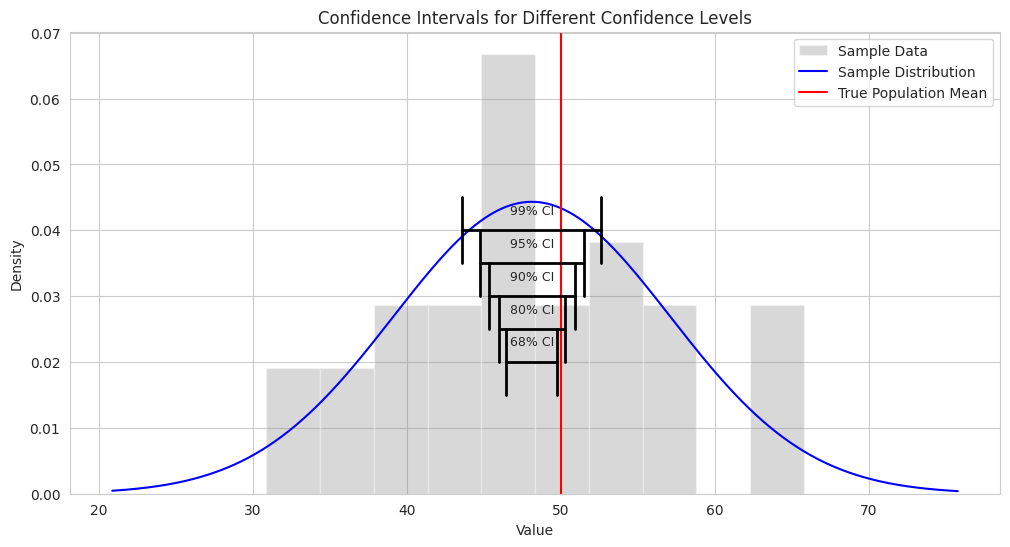

In [3]:
# Calculate 95% confidence interval for the mean
mean, ci_lower, ci_upper = mean_confidence_interval(sample)

print(f"95% Confidence Interval for the mean: [{ci_lower:.2f}, {ci_upper:.2f}]")

# Calculate confidence intervals for different confidence levels
confidence_levels = [0.68, 0.8, 0.9, 0.95, 0.99]
intervals = [mean_confidence_interval(sample, conf) for conf in confidence_levels]

# Visualize the confidence intervals
plt.figure(figsize=(12, 6))

# Plot sample data histogram
plt.hist(sample, bins=10, alpha=0.3, color='gray', density=True, label='Sample Data')

# Plot normal distribution with sample mean and std
x = np.linspace(min(sample) - 10, max(sample) + 10, 1000)
plt.plot(x, stats.norm.pdf(x, sample_mean, sample_std), 'b-', label='Sample Distribution')

# Add a vertical line for the true population mean
plt.axvline(true_mean, color='r', linestyle='-', label='True Population Mean')

# Add confidence intervals
for i, (conf, (m, lower, upper)) in enumerate(zip(confidence_levels, intervals)):
    plt.plot([lower, upper], [0.02 + i*0.005, 0.02 + i*0.005], 'k-', linewidth=2)
    plt.plot([lower, lower], [0.015 + i*0.005, 0.025 + i*0.005], 'k-', linewidth=2)
    plt.plot([upper, upper], [0.015 + i*0.005, 0.025 + i*0.005], 'k-', linewidth=2)
    plt.text((lower+upper)/2, 0.02 + i*0.005 + 0.002, f"{conf*100:.0f}% CI", 
             ha='center', va='bottom', fontsize=9)

plt.title('Confidence Intervals for Different Confidence Levels')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

Notice how the confidence interval widens as the confidence level increases. A 99% confidence interval is wider than a 95% confidence interval because we need to be more confident that the interval contains the true parameter.

## 3. Comparing Means: t-tests

The t-test is used to determine if there's a significant difference between the means of two groups. Let's generate two samples and perform a t-test.

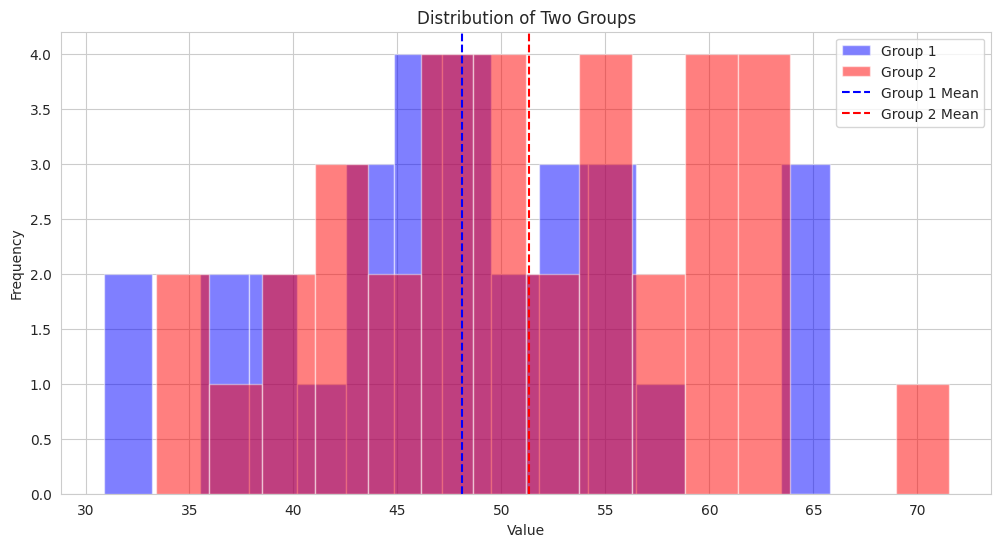

t-statistic: -1.4319
p-value: 0.1571
Interpretation: Fail to reject null hypothesis


In [4]:
# Generate two samples from normal distributions with slightly different means
np.random.seed(42)
group1_mean = 50
group2_mean = 53  # 3-point difference
common_std = 10
n1 = 30
n2 = 35

group1 = np.random.normal(group1_mean, common_std, n1)
group2 = np.random.normal(group2_mean, common_std, n2)

# Plot the data
plt.figure(figsize=(12, 6))
plt.hist(group1, bins=15, alpha=0.5, label='Group 1', color='blue')
plt.hist(group2, bins=15, alpha=0.5, label='Group 2', color='red')
plt.axvline(np.mean(group1), color='blue', linestyle='--', label='Group 1 Mean')
plt.axvline(np.mean(group2), color='red', linestyle='--', label='Group 2 Mean')
plt.title('Distribution of Two Groups')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Perform t-test
result = t_test(group1, group2)

print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"p-value: {result['p_value']:.4f}")
print(f"Interpretation: {result['interpretation']}")

Let's visualize the t-distribution and show the location of our test statistic:

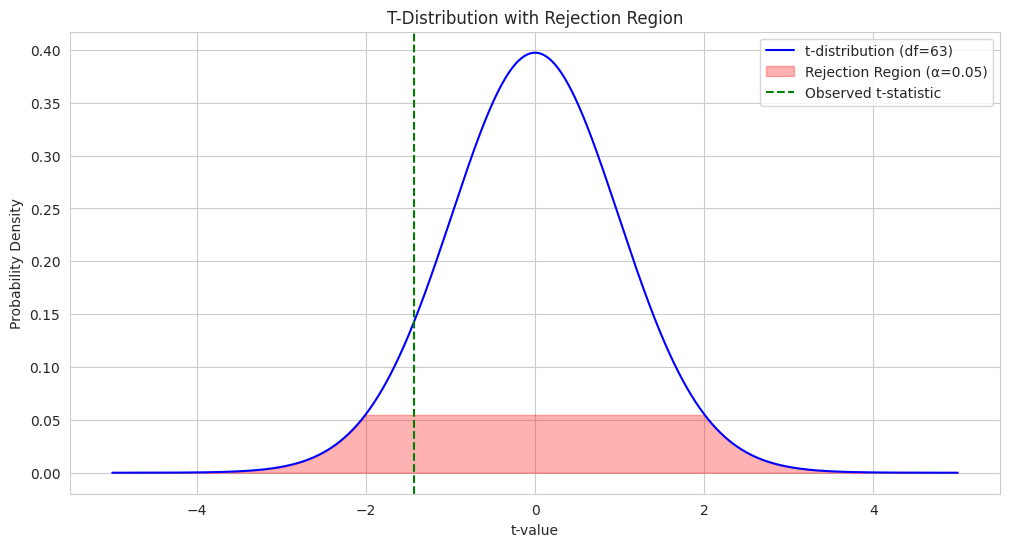

In [5]:
# Get the degrees of freedom
df = n1 + n2 - 2

# Create a range of t-values
t_values = np.linspace(-5, 5, 1000)
t_pdf = stats.t.pdf(t_values, df)

# Plot the t-distribution
plt.figure(figsize=(12, 6))
plt.plot(t_values, t_pdf, 'b-', label=f't-distribution (df={df})')

# Add the critical region
alpha = 0.05
critical_value = stats.t.ppf(1 - alpha/2, df)
rejection_region_x = np.concatenate([
    t_values[t_values <= -critical_value],
    t_values[t_values >= critical_value]
])
rejection_region_y = np.concatenate([
    t_pdf[t_values <= -critical_value],
    t_pdf[t_values >= critical_value]
])
plt.fill_between(rejection_region_x, rejection_region_y, alpha=0.3, color='red', label='Rejection Region (α=0.05)')

# Add the observed t-statistic
plt.axvline(result['t_statistic'], color='g', linestyle='--', label='Observed t-statistic')

plt.title('T-Distribution with Rejection Region')
plt.xlabel('t-value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

### Effects of Sample Size on t-test

Let's explore how sample size affects the power of the t-test, which is the probability of correctly rejecting a false null hypothesis.

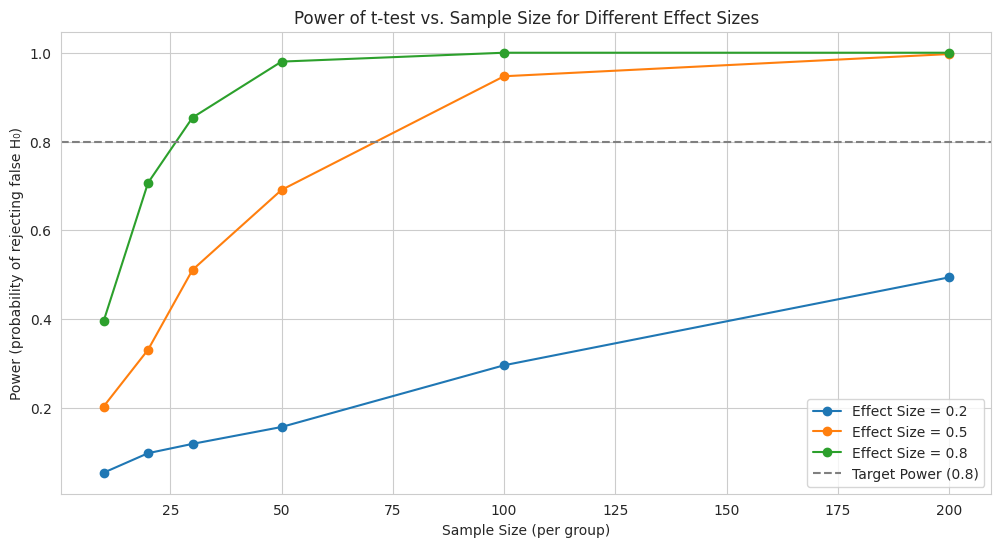

In [6]:
# Function to perform experiment and t-test with varying sample sizes
def power_experiment(mean1, mean2, std, sample_sizes, n_experiments=1000):
    """Calculate power of t-test for different sample sizes."""
    results = []
    
    for n in sample_sizes:
        significant_count = 0
        
        for _ in range(n_experiments):
            sample1 = np.random.normal(mean1, std, n)
            sample2 = np.random.normal(mean2, std, n)
            
            result = t_test(sample1, sample2)
            if result['significant']:
                significant_count += 1
        
        power = significant_count / n_experiments
        results.append(power)
    
    return results

# Set parameters
effect_sizes = [0.2, 0.5, 0.8]  # Small, medium, large effect sizes
std = 1.0
sample_sizes = [10, 20, 30, 50, 100, 200]
n_experiments = 1000

# Calculate power for different effect sizes
power_results = {}
for effect_size in effect_sizes:
    mean1 = 0.0
    mean2 = effect_size * std  # Effect size in standard deviations
    power_results[effect_size] = power_experiment(mean1, mean2, std, sample_sizes, n_experiments)

# Plot the results
plt.figure(figsize=(12, 6))
for effect_size, powers in power_results.items():
    plt.plot(sample_sizes, powers, 'o-', label=f'Effect Size = {effect_size}')

plt.axhline(0.8, color='gray', linestyle='--', label='Target Power (0.8)')
plt.title('Power of t-test vs. Sample Size for Different Effect Sizes')
plt.xlabel('Sample Size (per group)')
plt.ylabel('Power (probability of rejecting false H₀)')
plt.legend()
plt.grid(True)
plt.show()

Notice that for smaller effect sizes, you need much larger samples to achieve adequate power (typically 0.8 or higher). This is a key consideration in experimental design.

## 4. Chi-square Test for Goodness of Fit

The chi-square test is used to determine if the observed frequencies of values in a categorical variable follow an expected distribution. Let's demonstrate this with a dice-rolling example.

In [7]:
# Simulate rolling a die 500 times
np.random.seed(42)
fair_die = np.random.choice(np.arange(1, 7), size=500)

# Count occurrences of each value
observed_counts = np.array([np.sum(fair_die == i) for i in range(1, 7)])

# Expected counts for a fair die
expected_counts = np.ones(6) * (500 / 6)

# Perform chi-square test
result = chi_square_test(observed_counts, expected_counts)

print(f"Chi-square statistic: {result['chi2_statistic']:.4f}")
print(f"p-value: {result['p_value']:.4f}")
print(f"Interpretation: {result['interpretation']}")

Chi-square statistic: 5.0080
p-value: 0.4149
Interpretation: Fail to reject null hypothesis


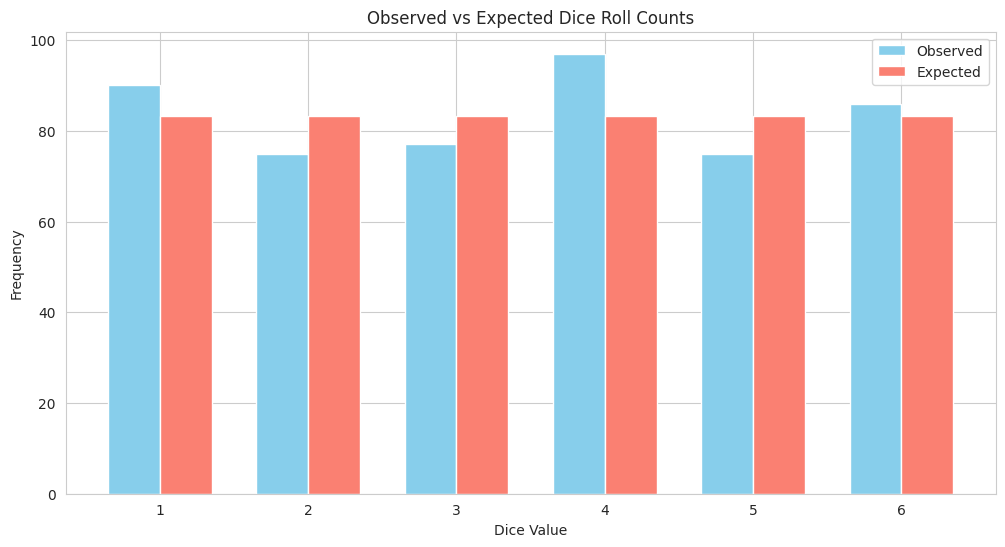

In [8]:
# Visualize the observed vs expected counts
plt.figure(figsize=(12, 6))
indices = np.arange(1, 7)
width = 0.35

plt.bar(indices - width/2, observed_counts, width, label='Observed', color='skyblue')
plt.bar(indices + width/2, expected_counts, width, label='Expected', color='salmon')

plt.title('Observed vs Expected Dice Roll Counts')
plt.xlabel('Dice Value')
plt.ylabel('Frequency')
plt.xticks(indices)
plt.legend()
plt.grid(True)
plt.show()

Now let's simulate a biased die and see if the chi-square test can detect it:

In [9]:
# Simulate a biased die: higher probabilities for 5 and 6
np.random.seed(42)
biased_probs = np.array([0.1, 0.1, 0.1, 0.1, 0.3, 0.3])
biased_die = np.random.choice(np.arange(1, 7), size=500, p=biased_probs)

# Count occurrences of each value
observed_counts_biased = np.array([np.sum(biased_die == i) for i in range(1, 7)])

# Perform chi-square test
result_biased = chi_square_test(observed_counts_biased, expected_counts)

print(f"Chi-square statistic: {result_biased['chi2_statistic']:.4f}")
print(f"p-value: {result_biased['p_value']:.4f}")
print(f"Interpretation: {result_biased['interpretation']}")

Chi-square statistic: 148.8640
p-value: 0.0000
Interpretation: Reject null hypothesis (distributions differ)


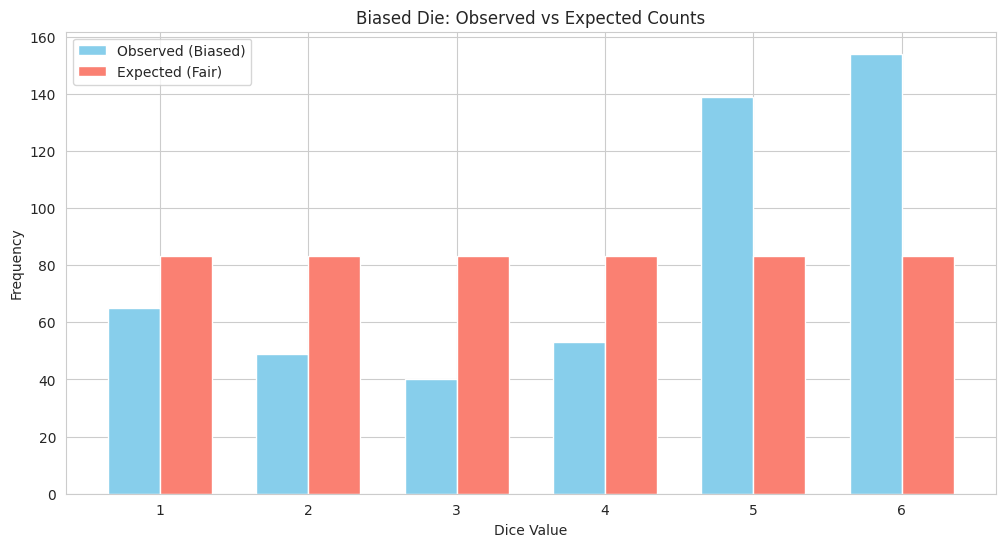

In [10]:
# Visualize the biased die results
plt.figure(figsize=(12, 6))
indices = np.arange(1, 7)
width = 0.35

plt.bar(indices - width/2, observed_counts_biased, width, label='Observed (Biased)', color='skyblue')
plt.bar(indices + width/2, expected_counts, width, label='Expected (Fair)', color='salmon')

plt.title('Biased Die: Observed vs Expected Counts')
plt.xlabel('Dice Value')
plt.ylabel('Frequency')
plt.xticks(indices)
plt.legend()
plt.grid(True)
plt.show()

## 5. Bootstrap Confidence Intervals

Bootstrapping is a resampling technique used to estimate the sampling distribution of a statistic. It's particularly useful when the theoretical distribution is unknown or when dealing with complex statistics.

In [11]:
# Generate a non-normal sample from an exponential distribution
np.random.seed(42)
exp_sample = np.random.exponential(scale=5.0, size=100)

# Calculate bootstrap confidence interval for the mean
mean, lower, upper = bootstrap_confidence_interval(exp_sample, np.mean)

print(f"Bootstrap 95% CI for mean: [{lower:.2f}, {upper:.2f}]")

# Calculate bootstrap confidence interval for the median
median, lower_m, upper_m = bootstrap_confidence_interval(exp_sample, np.median)

print(f"Bootstrap 95% CI for median: [{lower_m:.2f}, {upper_m:.2f}]")

Bootstrap 95% CI for mean: [3.69, 5.50]
Bootstrap 95% CI for median: [2.01, 4.12]


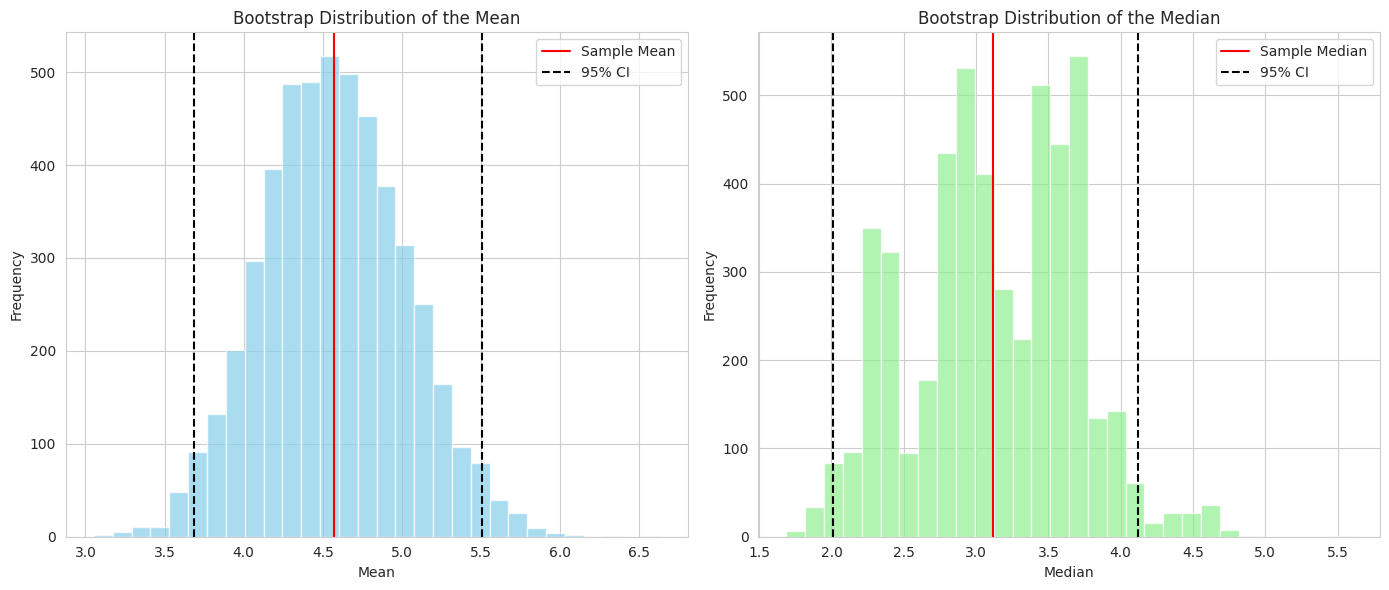

In [12]:
# Visualize the bootstrap distribution
n_resamples = 5000
bootstrap_means = []
bootstrap_medians = []

for _ in range(n_resamples):
    resample = np.random.choice(exp_sample, size=len(exp_sample), replace=True)
    bootstrap_means.append(np.mean(resample))
    bootstrap_medians.append(np.median(resample))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot bootstrap distribution of the mean
ax1.hist(bootstrap_means, bins=30, alpha=0.7, color='skyblue')
ax1.axvline(mean, color='r', linestyle='-', label='Sample Mean')
ax1.axvline(lower, color='k', linestyle='--', label='95% CI')
ax1.axvline(upper, color='k', linestyle='--')
ax1.set_title('Bootstrap Distribution of the Mean')
ax1.set_xlabel('Mean')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True)

# Plot bootstrap distribution of the median
ax2.hist(bootstrap_medians, bins=30, alpha=0.7, color='lightgreen')
ax2.axvline(median, color='r', linestyle='-', label='Sample Median')
ax2.axvline(lower_m, color='k', linestyle='--', label='95% CI')
ax2.axvline(upper_m, color='k', linestyle='--')
ax2.set_title('Bootstrap Distribution of the Median')
ax2.set_xlabel('Median')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. Permutation Tests

Permutation tests are a type of resampling test where the null hypothesis corresponds to two groups having identical probability distributions. The test works by repeatedly shuffling the data between the two groups.

In [13]:
# Generate data for two groups with a small difference
np.random.seed(42)
group_a = np.random.normal(10, 2, 30)
group_b = np.random.normal(11, 2, 30)  # 1-unit difference in mean

# Perform permutation test
result = permutation_test(group_a, group_b)

print(f"Observed difference in means: {result['observed_statistic']:.4f}")
print(f"Permutation test p-value: {result['p_value']:.4f}")
print(f"Interpretation: {result['interpretation']}")

Observed difference in means: -1.1340
Permutation test p-value: 0.0196
Interpretation: Reject null hypothesis (samples differ)


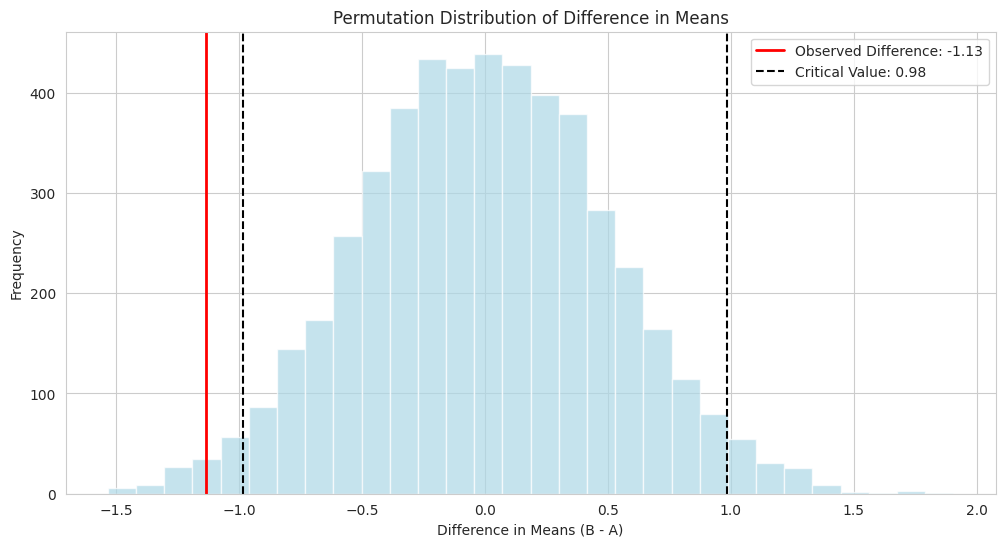

In [14]:
# Visualize the permutation distribution
n_permutations = 5000
combined = np.concatenate([group_a, group_b])
perm_diffs = []

for _ in range(n_permutations):
    np.random.shuffle(combined)
    perm_a = combined[:len(group_a)]
    perm_b = combined[len(group_a):]
    perm_diffs.append(np.mean(perm_b) - np.mean(perm_a))

plt.figure(figsize=(12, 6))
plt.hist(perm_diffs, bins=30, alpha=0.7, color='lightblue')
plt.axvline(result['observed_statistic'], color='r', linestyle='-', linewidth=2, 
            label=f"Observed Difference: {result['observed_statistic']:.2f}")

# Add rejection regions
critical_value = np.percentile(np.abs(perm_diffs), 95)
plt.axvline(critical_value, color='k', linestyle='--', label=f"Critical Value: {critical_value:.2f}")
plt.axvline(-critical_value, color='k', linestyle='--')

plt.title('Permutation Distribution of Difference in Means')
plt.xlabel('Difference in Means (B - A)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## 7. Type I and Type II Errors

In hypothesis testing, there are two types of errors:
- **Type I Error**: Rejecting a true null hypothesis (false positive)
- **Type II Error**: Failing to reject a false null hypothesis (false negative)

Let's simulate these errors for t-tests:

In [15]:
# Simulate Type I and Type II errors
def simulate_errors(n_trials=1000, sample_size=30, true_diff=0, alpha=0.05):
    """Simulate hypothesis tests and count errors."""
    
    type_I_count = 0
    type_II_count = 0
    p_values = []
    
    for _ in range(n_trials):
        # Generate two samples
        group1 = np.random.normal(0, 1, sample_size)
        group2 = np.random.normal(0 + true_diff, 1, sample_size)
        
        # Perform t-test
        result = t_test(group1, group2)
        p_values.append(result['p_value'])
        
        # Count errors
        if true_diff == 0 and result['significant']:
            # Type I error: rejected H0 when it's true
            type_I_count += 1
        elif true_diff != 0 and not result['significant']:
            # Type II error: failed to reject H0 when it's false
            type_II_count += 1
    
    if true_diff == 0:
        type_I_rate = type_I_count / n_trials
        return type_I_rate, None, p_values
    else:
        type_II_rate = type_II_count / n_trials
        power = 1 - type_II_rate
        return None, power, p_values

In [16]:
# Simulate Type I error (null hypothesis is true)
type_I_rate, _, p_values_null = simulate_errors(n_trials=5000, true_diff=0)

print(f"Type I error rate (should be close to alpha=0.05): {type_I_rate:.4f}")

# Simulate tests when alternative hypothesis is true
_, power, p_values_alt = simulate_errors(n_trials=5000, true_diff=0.5)

print(f"Power (when true difference = 0.5): {power:.4f}")

Type I error rate (should be close to alpha=0.05): 0.0524
Power (when true difference = 0.5): 0.4810


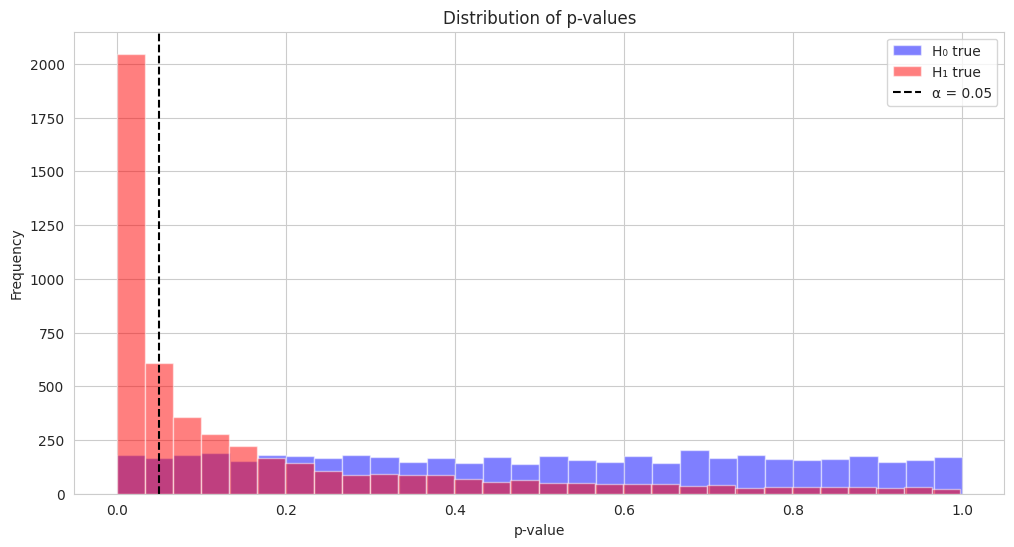

In [17]:
# Plot p-value distributions
plt.figure(figsize=(12, 6))

plt.hist(p_values_null, bins=30, alpha=0.5, label='H₀ true', color='blue')
plt.hist(p_values_alt, bins=30, alpha=0.5, label='H₁ true', color='red')
plt.axvline(0.05, color='k', linestyle='--', label='α = 0.05')

plt.title('Distribution of p-values')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

Notice that when the null hypothesis is true, p-values are uniformly distributed. When the alternative hypothesis is true, p-values are skewed toward 0.

## Conclusion

In this notebook, we've explored statistical tests and hypothesis testing, including:

1. Confidence intervals for estimating population parameters
2. t-tests for comparing means between two groups
3. Chi-square tests for goodness of fit
4. Bootstrap methods for non-parametric inference
5. Permutation tests for comparing distributions
6. Type I and Type II errors in hypothesis testing

These statistical methods form the foundation for many data analysis and machine learning techniques, allowing us to make informed decisions based on data and quantify the uncertainty in our conclusions.